In [1]:
import numpy as np
import pandas as pd
import json
import urllib.request

In [2]:
#29.84284299232534, -95.91013718012503

In [4]:
url = 'https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline' + \
  '/29.84284299232534,-95.91013718012503/2026-04-17/2026-04-24?unitGroup=metric&elements=datetimeEpoch,solarradiation' + \
  '&key=298LYYNTAZVEU5JN67C8W5AQE&contentType=json'

In [17]:
response = urllib.request.urlopen(url).read()


In [24]:
data = json.loads(response)
lists = []
for day in data['days']:
    for hour_data in day['hours']:
        from datetime import datetime
        time = datetime.fromtimestamp(hour_data['datetimeEpoch'])
        solar_radiation = [time, hour_data['solarradiation']]
        lists.append(solar_radiation)

In [15]:
df_solar = pd.DataFrame(lists, columns=['time', 'solar_radiation'])
df_solar

,time,solar_radiation
0,2026-04-16 22:00:00,0.0
1,2026-04-16 23:00:00,0.0
2,2026-04-17 00:00:00,0.0
3,2026-04-17 01:00:00,0.0
4,2026-04-17 02:00:00,0.0
...,...,...
187,2026-04-24 17:00:00,549.0
188,2026-04-24 18:00:00,370.0
189,2026-04-24 19:00:00,192.0
190,2026-04-24 20:00:00,13.0


<Axes: title={'center': 'Solar radiation'}, xlabel='Time', ylabel='Solar radiation (W/m2)'>

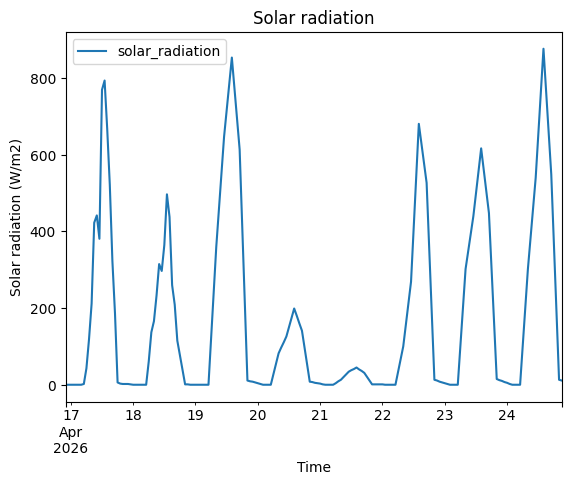

In [20]:
df_solar.set_index('time', inplace=True)
df_solar.plot(kind='line', title='Solar radiation', xlabel='Time', ylabel='Solar radiation (W/m2)')


In [25]:
efficiency = .2
panel_area = 2
num_panels = 600
total_area = num_panels * panel_area
print(total_area, 'm2')

1200 m2


,solar_radiation,pv
time,,
2026-04-16 22:00:00,0.0,0.00
2026-04-16 23:00:00,0.0,0.00
2026-04-17 00:00:00,0.0,0.00
2026-04-17 01:00:00,0.0,0.00
2026-04-17 02:00:00,0.0,0.00
...,...,...
2026-04-24 17:00:00,549.0,131.76
2026-04-24 18:00:00,370.0,88.80
2026-04-24 19:00:00,192.0,46.08


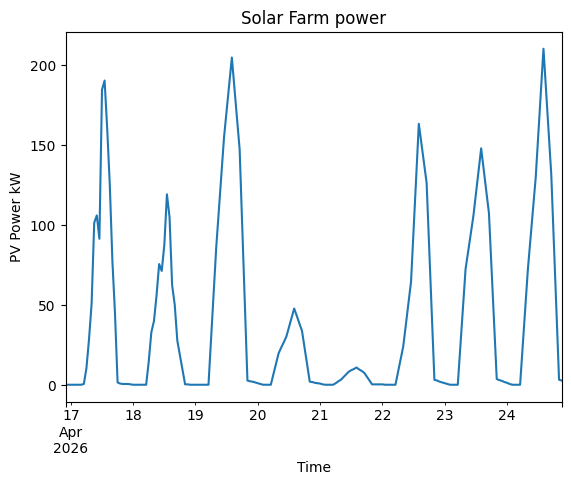

In [37]:
df_solar['pv'] = df_solar['solar_radiation'] * efficiency * total_area / 1000
df_solar['pv'].plot(kind='line', title='Solar Farm power', xlabel='Time', ylabel='PV Power kW')

In [56]:
from datetime import date
df_solar.index = pd.to_datetime(df_solar.index)
df_solar['date'] = df_solar.index.date
df_today = df_solar[df_solar['date'] == date.today()]
total_energy = df_today['pv'].sum()
total_energy

np.float64(1176.24)